# Logistic Regression — Chicago Training & NIBRS Generalization

This notebook follows:
- **NIBRS Test Dataset Usage Guide**: train on Chicago feature-engineered data, align features, evaluate on NIBRS (`X_test_nibrs.csv`, `y_test_nibrs.csv`).
- **NIBRS Metadata Usage Guide**: optional post-hoc merge with `nibrs_meta.csv` for analysis only (not model features).

**Paths (from `notebooks/`):**
- Chicago: `../data/feature_engineering/`
- NIBRS: `../data/nibrs/`

## 1. Imports and configuration

In [1]:
# --- Standard libraries ---
import pandas as pd
import numpy as np
from pathlib import Path

# --- Scikit-learn ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt
from IPython.display import display  # Pretty tables in Jupyter

# --- Paths (notebook runs from notebooks/ directory) ---
FEATURE_DIR = Path("../data/feature_engineering")
NIBRS_DIR = Path("../data/nibrs")
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

## 2. Load Chicago train/test (feature engineering)

Same splits as the baseline logistic notebook. `y` uses column `hotspot`.

In [2]:
X_train = pd.read_csv(FEATURE_DIR / "X_train.csv")
X_test_chicago = pd.read_csv(FEATURE_DIR / "X_test.csv")
y_train = pd.read_csv(FEATURE_DIR / "y_train.csv").squeeze()
y_test_chicago = pd.read_csv(FEATURE_DIR / "y_test.csv").squeeze()

print("Chicago shapes:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_test:  {X_test_chicago.shape}, y_test: {y_test_chicago.shape}")

Chicago shapes:
  X_train: (539, 35), y_train: (539,)
  X_test:  (77, 35), y_test: (77,)


## 3. Align features with NIBRS (drop geo / Chicago-only columns)

Per **NIBRS Test Dataset Usage Guide**: remove `lat_mean`, `lon_mean`, and all `district_*` dummies so the feature space matches NIBRS (crime and location ratios only).

In [3]:
# Columns not present in NIBRS test features — must drop from both Chicago and before alignment
drop_cols = ["lat_mean", "lon_mean"] + [
    col for col in X_train.columns if col.startswith("district_")
]

X_train_aligned = X_train.drop(columns=drop_cols, errors="ignore").copy()
X_test_chicago_aligned = X_test_chicago.drop(columns=drop_cols, errors="ignore").copy()

print(f"Aligned feature count: {X_train_aligned.shape[1]}")
print("Columns:", list(X_train_aligned.columns))

Aligned feature count: 11
Columns: ['commercial_ratio', 'institution_ratio', 'other_ratio', 'public_ratio', 'residential_ratio', 'theft_ratio', 'battery_ratio', 'criminal_damage_ratio', 'assault_ratio', 'deceptive_practice_ratio', 'other_crime_ratio']


## 4. Train logistic regression (Chicago, aligned features)

`class_weight='balanced'` helps with imbalanced hotspot labels.

In [4]:
model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    solver="lbfgs",
    class_weight="balanced",
)
model.fit(X_train_aligned, y_train)
print("Training complete on aligned Chicago features.")

Training complete on aligned Chicago features.


## 5. Baseline: evaluate on Chicago test (aligned)

Reference performance before NIBRS transfer.

In [5]:
y_pred_chicago = model.predict(X_test_chicago_aligned)
y_proba_chicago = model.predict_proba(X_test_chicago_aligned)[:, 1]

print("--- Chicago test (aligned) ---")
print(f"Accuracy : {accuracy_score(y_test_chicago, y_pred_chicago):.4f}")
print(f"Precision: {precision_score(y_test_chicago, y_pred_chicago, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test_chicago, y_pred_chicago, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_test_chicago, y_pred_chicago, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test_chicago, y_proba_chicago):.4f}")
print(classification_report(y_test_chicago, y_pred_chicago, target_names=["Non-hotspot", "Hotspot"]))

--- Chicago test (aligned) ---
Accuracy : 0.5195
Precision: 0.3265
Recall   : 0.8000
F1       : 0.4638
ROC-AUC  : 0.6719
              precision    recall  f1-score   support

 Non-hotspot       0.86      0.42      0.56        57
     Hotspot       0.33      0.80      0.46        20

    accuracy                           0.52        77
   macro avg       0.59      0.61      0.51        77
weighted avg       0.72      0.52      0.54        77



## 6. Load NIBRS test data (merge X and y)

Per guide: each row is one agency; labels from 2024 (top 25% hotspot definition).

In [6]:
X_nibrs_raw = pd.read_csv(NIBRS_DIR / "X_test_nibrs.csv")
y_nibrs_df = pd.read_csv(NIBRS_DIR / "y_test_nibrs.csv")

# Inner merge keeps agencies with both features and labels
data_nibrs = X_nibrs_raw.merge(y_nibrs_df, on="agency_id", how="inner")

# Model input: drop identifiers and target; target column is "label"
y_nibrs = data_nibrs["label"]
agency_ids = data_nibrs["agency_id"].copy()
X_nibrs_model = data_nibrs.drop(columns=["agency_id", "label"], errors="ignore")

print(f"NIBRS merged rows: {len(data_nibrs)}, feature columns: {X_nibrs_model.shape[1]}")

NIBRS merged rows: 1914, feature columns: 11


## 7. Align NIBRS columns to training columns

Per guide: `reindex` to `X_train_aligned.columns`, `fill_value=0` for any missing columns.

In [7]:
X_nibrs_aligned = X_nibrs_model.reindex(columns=X_train_aligned.columns, fill_value=0)

# Sanity check: same columns and order as training
assert list(X_nibrs_aligned.columns) == list(X_train_aligned.columns)
print("Column alignment OK.")

Column alignment OK.


## 8. Predict and evaluate on NIBRS (generalization)

This measures how well the Chicago-trained model transfers to NIBRS agencies.

In [8]:
y_pred_nibrs = model.predict(X_nibrs_aligned)
y_proba_nibrs = model.predict_proba(X_nibrs_aligned)[:, 1]

print("--- NIBRS test (out-of-domain) ---")
print(f"Accuracy : {accuracy_score(y_nibrs, y_pred_nibrs):.4f}")
print(f"Precision: {precision_score(y_nibrs, y_pred_nibrs, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_nibrs, y_pred_nibrs, zero_division=0):.4f}")
print(f"F1       : {f1_score(y_nibrs, y_pred_nibrs, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_nibrs, y_proba_nibrs):.4f}")
print(classification_report(y_nibrs, y_pred_nibrs, target_names=["Non-hotspot", "Hotspot"]))

--- NIBRS test (out-of-domain) ---
Accuracy : 0.4577
Precision: 0.3018
Recall   : 0.8253
F1       : 0.4419
ROC-AUC  : 0.5659
              precision    recall  f1-score   support

 Non-hotspot       0.84      0.33      0.47      1416
     Hotspot       0.30      0.83      0.44       498

    accuracy                           0.46      1914
   macro avg       0.57      0.58      0.46      1914
weighted avg       0.70      0.46      0.46      1914



## 9. Confusion matrix and ROC — NIBRS

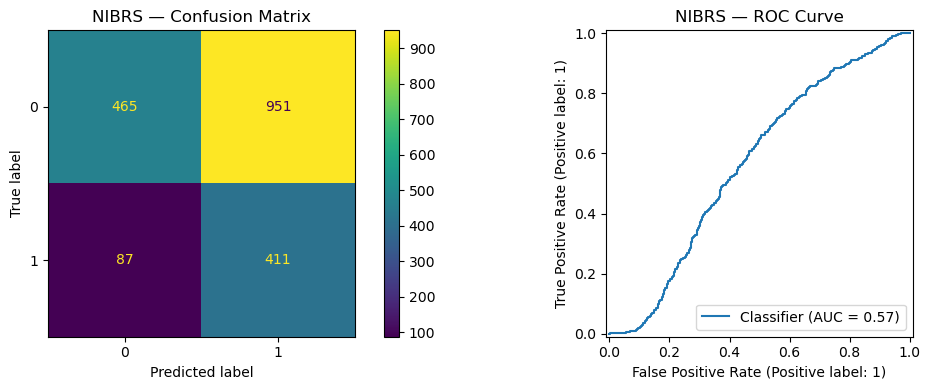

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_nibrs, y_pred_nibrs, ax=axes[0])
axes[0].set_title("NIBRS — Confusion Matrix")
RocCurveDisplay.from_predictions(y_nibrs, y_proba_nibrs, ax=axes[1])
axes[1].set_title("NIBRS — ROC Curve")
plt.tight_layout()
plt.show()

## 10. Cross-validation (Chicago train, aligned features)

Stratified 5-fold ROC-AUC on training data only (no leakage from NIBRS).

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    model, X_train_aligned, y_train, cv=cv, scoring="roc_auc"
)
print(f"5-Fold CV ROC-AUC (Chicago train): {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

5-Fold CV ROC-AUC (Chicago train): 0.7686 (+/- 0.1099)


## 11. Feature coefficients (aligned model)

Interpretation: effect on log-odds of hotspot vs non-hotspot.

,feature,coefficient
3,public_ratio,2.801395
6,battery_ratio,1.551153
0,commercial_ratio,1.486283
5,theft_ratio,1.212344
10,other_crime_ratio,0.954653
1,institution_ratio,0.000360
8,assault_ratio,-0.004016
7,criminal_damage_ratio,-1.851123
9,deceptive_practice_ratio,-1.862247
2,other_ratio,-1.892240


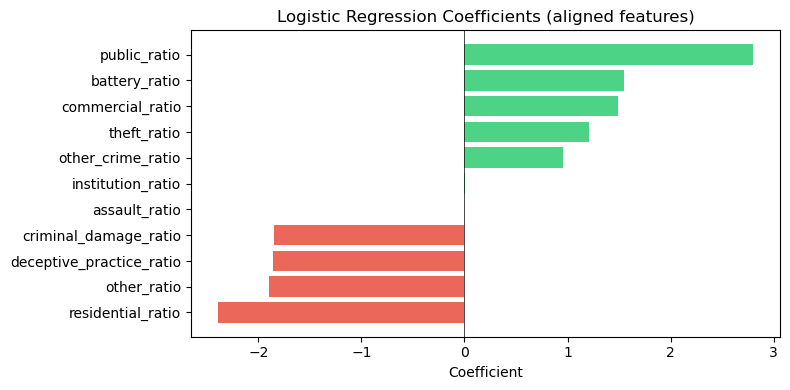

In [11]:
coef_df = pd.DataFrame(
    {"feature": X_train_aligned.columns, "coefficient": model.coef_[0]}
).sort_values("coefficient", ascending=False)

display(coef_df)

fig, ax = plt.subplots(figsize=(8, max(4, 0.25 * len(coef_df))))
coef_sorted = coef_df.sort_values("coefficient", ascending=True)
colors = ["#e74c3c" if c < 0 else "#2ecc71" for c in coef_sorted["coefficient"]]
ax.barh(coef_sorted["feature"], coef_sorted["coefficient"], color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Coefficient")
ax.set_title("Logistic Regression Coefficients (aligned features)")
plt.tight_layout()
plt.show()

## 12. Optional: NIBRS metadata for post-hoc analysis only

Per **NIBRS Metadata Usage Guide**: `nibrs_meta.csv` is **not** for model input. Merge predictions with metadata to analyze performance by state, region, or agency type.

In [12]:
meta_path = NIBRS_DIR / "nibrs_meta.csv"
if meta_path.exists():
    meta = pd.read_csv(meta_path)

    # Attach predictions and probabilities for analysis
    results_df = pd.DataFrame({
        "agency_id": agency_ids.values,
        "y_true": y_nibrs.values,
        "y_pred": y_pred_nibrs,
        "y_proba": y_proba_nibrs,
    })
    analysis_df = results_df.merge(meta, on="agency_id", how="left")

    # Example: mean true label (hotspot rate) by state
    print("Mean label (hotspot rate) by state_name:")
    print(analysis_df.groupby("state_name")["y_true"].mean().sort_values(ascending=False).head(10))

    # Example: mean predicted probability by agency type
    print("\nMean predicted P(hotspot) by agency_type_name:")
    print(analysis_df.groupby("agency_type_name")["y_proba"].mean().sort_values(ascending=False))
else:
    print(f"Metadata not found at {meta_path}; skip post-hoc merge.")

Mean label (hotspot rate) by state_name:
state_name
California    0.423408
New York      0.266667
Texas         0.173647
Name: y_true, dtype: float64

Mean predicted P(hotspot) by agency_type_name:
agency_type_name
State Police             0.915149
Other                    0.660391
City                     0.610838
University or College    0.595265
Other State Agency       0.503693
County                   0.483007
Tribal                   0.459403
Name: y_proba, dtype: float64


In [13]:
import os
import joblib

os.makedirs('../src/models', exist_ok=True)

joblib.dump(model, '../src/models/lr_nibrs.pkl')

print('Model saved to src/models/lr_nibrs.pkl')

Model saved to src/models/lr_nibrs.pkl


In [15]:
import joblib
from pathlib import Path

model_dir = Path("../src/models")

rf_model = joblib.load(model_dir / "best_rf_nibrs.pkl")
xgb_model = joblib.load(model_dir / "xgboost_hotspot_nibrs.pkl")
lr_model = joblib.load(model_dir / "lr_nibrs.pkl")

models = {
    "rf": rf_model,
    "xgb": xgb_model,
    "lr": lr_model
}

for name, model in models.items():
    print(f"\nModel: {name}")

    if hasattr(model, "feature_names_in_"):
        print("Feature names found")
        print("Number of features:", len(model.feature_names_in_))
        print(model.feature_names_in_)
    elif hasattr(model, "n_features_in_"):
        print("Feature count found")
        print("Number of features:", model.n_features_in_)
    else:
        print("No stored feature metadata found")


Model: rf
Feature names found
Number of features: 11
['commercial_ratio' 'institution_ratio' 'other_ratio' 'public_ratio'
 'residential_ratio' 'theft_ratio' 'battery_ratio' 'criminal_damage_ratio'
 'assault_ratio' 'deceptive_practice_ratio' 'other_crime_ratio']

Model: xgb
Feature names found
Number of features: 11
['commercial_ratio' 'institution_ratio' 'other_ratio' 'public_ratio'
 'residential_ratio' 'theft_ratio' 'battery_ratio' 'criminal_damage_ratio'
 'assault_ratio' 'deceptive_practice_ratio' 'other_crime_ratio']

Model: lr
Feature names found
Number of features: 11
['commercial_ratio' 'institution_ratio' 'other_ratio' 'public_ratio'
 'residential_ratio' 'theft_ratio' 'battery_ratio' 'criminal_damage_ratio'
 'assault_ratio' 'deceptive_practice_ratio' 'other_crime_ratio']


/opt/anaconda3/envs/xgb_fix/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/xgb_fix/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
